In [1]:
import polars as pl
import polars.selectors as cs
from hta.trace_analysis import TraceAnalysis
import pandas as pd
import glob
import os

In [2]:
power_labels = [
    "IBP,",        "ICP,",        "DCP,",      "TCP,",      "CCP,",
    "SHRDP,",      "RFP,",        "INTP,",     "FPUP,",     "DPUP,",
    "INT_MUL24P,", "INT_MUL32P,", "INT_MULP,", "INT_DIVP,", "FP_MULP,",
    "FP_DIVP,",    "FP_SQRTP,",   "FP_LGP,",   "FP_SINP,",  "FP_EXP,",
    "DP_MULP,",    "DP_DIVP,",    "TENSORP,",  "TEXP,",     "SCHEDP,",
    "L2CP,",       "MCP,",        "NOCP,",     "DRAMP,",    "PIPEP,",
    "IDLE_COREP,", "CONSTP",      "STATICP"
]

In [3]:
df = (
    pl.scan_csv(
        "/users/zarand1a/accel-sim-framework/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_power_report.log", 
        has_header=False, 
        separator="?", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*/accelwattch_power_report.log")
        .alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)

In [4]:
power_df = (
    (
        df.filter(pl.col("data").str.starts_with("gpu_avg_"))
        .select(
            "index",
            pl.col("data")
            .str.replace("^gpu_avg_", "")
            .str.replace_all(" ", "")
            .str.splitn("=", 2)
            .struct.rename_fields(["label", "value"])
            .struct.with_fields(pl.field("value").cast(float))
            .struct.unnest()
        )
    )
    .join_asof(
        df.filter(pl.col("data").str.starts_with("kernel_name"))
        .select(
            pl.col("index"),
            pl.col("index").rank("dense").over("benchmark").alias("serial"),
            pl.col("benchmark"),
            pl.col("data").str.extract("kernel_name = (.*)").alias("kernel")
        ),
        on="index",
    )
    .drop("index")
    .group_by("benchmark", "serial", "kernel", "label").agg(pl.mean("value"))
    .pivot(on="label", index=["benchmark", "serial", "kernel"])
    .select("benchmark", "serial", "kernel", *power_labels)
    .with_columns(
        pl.col("DRAMP,") + pl.col("MCP,"),
        pl.col("L2CP,") + pl.col("NOCP,"),
    )
    .rename(lambda col: col.replace(",", ""))
    .unpivot(index=["benchmark", "serial", "kernel"], value_name="power_w")
    .group_by("benchmark", "serial", "kernel")
    .agg(pl.sum("power_w"))
    .sort("benchmark", "serial", "kernel")
)

In [5]:
df = (
    pl.scan_csv("/users/zarand1a/accel-sim-framework/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/*-NO_ARGS.*",
        has_header=False, 
        separator="&", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*")
        .alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)

In [6]:
cycle_df = (
    df.filter(pl.col("data").str.starts_with("kernel_name ="))
    .select(
        "index", "benchmark",
        pl.col("data").str.extract("kernel_name = (.*)").alias("kernel"),
    )
).join(
    df.filter(pl.col("data").str.starts_with("gpu_sim_cycle ="))
    .select(
        pl.col("index") - 3,
        pl.col("data").str.extract("gpu_sim_cycle = (.*)").cast(int).alias("cycle"),
    ),
    on="index",
).select(
    "benchmark",
    pl.col("index").rank("dense").over("benchmark").alias("serial"),
    "kernel", "cycle",
)

In [17]:
accel_df = (
    power_df.join(cycle_df, on=["benchmark", "serial", "kernel"])
    .filter(pl.col("power_w").is_not_nan())
    .group_by("benchmark")
    .agg(
        power_w=(pl.col("power_w") * pl.col("cycle")).sum() / pl.col("cycle").sum(),
        cycles=pl.col("cycle").sum()
    )
)

In [18]:
df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/power_logs/*-power.0.csv", 
        include_file_paths="path",
    )
    .with_columns(
        pl.col("path").str.extract(r"/proj/threadtune-PG0/amir/power_logs/(.*)-power.0.csv")
        .alias("benchmark"),
    )
    .drop("path")
    .collect()
)

In [29]:
measure_df = (
    df.group_by("benchmark")
    .agg(
        power_w=(
            pl.col("total_energy_millijoules").max() - pl.col("total_energy_millijoules").min()
        ) / (
            pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()
        ) * 1e6,
        time_us = (pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()) / 10000 / 1000
    )
)

In [43]:
comp_df = (
    accel_df.rename({"power_w": "accel_power_W"})
    .with_columns(
        (pl.col("cycles") / 1132).alias("accel_time_us")
    ).drop("cycles")
    .join(measure_df.rename({"power_w": "measured_power_W", "time_us": "measured_time_us"}), on="benchmark")
)
comp_df

benchmark,accel_power_W,accel_time_us,measured_power_W,measured_time_us
str,f64,f64,f64,f64
"""gpt2""",92.793675,4602.412544,38.570944,22697.103064
"""bloom""",112.715731,7289.7553,74.344924,15222.401692
"""bert""",96.99283,2454.583039,59.101363,10755.061665
"""gpt2-train""",109.122387,43136.380742,89.669436,52817.232234
"""deit-train""",97.265104,15601.258834,68.242799,45746.64186
…,…,…,…,…
"""resnet50""",92.827203,4853.968198,54.032302,41119.958221
"""deit""",91.044472,7152.356007,54.731851,41999.117103
"""gemma-train""",167.871848,7767.30212,82.827927,204929.481581


In [ ]:
kineto_df = pl.read_json("/proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json").select(pl.col("traceEvents").explode().struct.unnest())
kineto_df.filter(pl.col("cat") == "Trace").select("dur") - kineto_df.filter(pl.col("cat") == "kernel").select("dur").sum()


dur
f64
631781.294


In [49]:
kineto_df.filter(pl.col("cat") == "Trace").select("dur")

dur
f64
503843.15


In [52]:
kineto_df.filter(pl.col("cat") == "kernel").select("dur").sum()

dur
f64
11454.619


In [45]:
xml_df = (
    pl.scan_csv(
        "/users/zarand1a/accel-sim-framework/sim_run_12.8/bert/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_sass_sim.xml", 
        separator="\x1f",
        has_header=False, 
        new_columns=["line"],
        quote_char=None
    )
    .filter(pl.col("line").str.contains('name="constant_power"'))
    .select(
        pl.col("line")
        .str.extract(r'value="([\d\.]+)"', 1)
        .cast(pl.Float64)
    )
    .collect()
)
constant_power = xml_df.item()
print(f"Constant Power: {constant_power}")

Constant Power: 32.32522272


In [46]:
kineto_root = "/proj/threadtune-PG0/amir/kineto_traces/*"
xml_base_path = "/users/zarand1a/accel-sim-framework/sim_run_12.8"

results = []

for trace_dir in glob.glob(kineto_root):
    full_benchmark_name = os.path.basename(trace_dir)
    
    if "-inference" in full_benchmark_name:
        benchmark_name = full_benchmark_name.replace("-inference", "")
        xml_model_name = benchmark_name
    else:
        benchmark_name = full_benchmark_name
        xml_model_name = full_benchmark_name

    print(f"Processing: {full_benchmark_name} (Cleaned: {benchmark_name})")

    json_path = os.path.join(trace_dir, "device.0.json")
    
    if not os.path.exists(json_path):
        print(f"  Skipping: {json_path} not found.")
        continue

    try:
        kineto_df = (
            pl.read_json(json_path)
            .select(pl.col("traceEvents").explode().struct.unnest())
        )

        total_trace_dur = kineto_df.filter(pl.col("cat") == "Trace").select(pl.col("dur")).sum().item()
        total_kernel_dur = kineto_df.filter(pl.col("cat") == "kernel").select(pl.col("dur")).sum().item()

        if total_trace_dur is None: total_trace_dur = 0
        if total_kernel_dur is None: total_kernel_dur = 0
        
        idle_time_us = total_trace_dur - total_kernel_dur

    except Exception as e:
        print(f"  Error reading Kineto trace: {e}")
        continue

    xml_path = f"{xml_base_path}/{xml_model_name}/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_sass_sim.xml"
    
    if not os.path.exists(xml_path):
        print(f"  Warning: XML not found at {xml_path}")
        constant_power = None
        idle_energy = None
    else:
        try:
            xml_df = (
                pl.scan_csv(
                    xml_path, 
                    separator="\x1f", 
                    has_header=False, 
                    new_columns=["line"],
                    quote_char=None
                )
                .filter(pl.col("line").str.contains('name="constant_power"'))
                .select(
                    pl.col("line")
                    .str.extract(r'value="([\d\.]+)"', 1)
                    .cast(pl.Float64)
                )
                .collect()
            )
            
            if xml_df.height > 0:
                constant_power = xml_df.item()
                
                idle_energy = idle_time_us * constant_power
            else:
                constant_power = None
                idle_energy = None
                
        except Exception as e:
            print(f"  Error parsing XML: {e}")
            constant_power = None
            idle_energy = None

    results.append({
        "benchmark": benchmark_name,
        "idle_time_us": idle_time_us,
        "constant_power_W": constant_power,
        "idle_energy_uJ": idle_energy
    })

idle_df = pl.DataFrame(results)

Processing: deit-train (Cleaned: deit-train)
Processing: gpt2-inference (Cleaned: gpt2)
Processing: bloom-train (Cleaned: bloom-train)
Processing: resnet50-train (Cleaned: resnet50-train)
Processing: gpt2-train (Cleaned: gpt2-train)
Processing: resnet50-inference (Cleaned: resnet50)
Processing: bert-inference (Cleaned: bert)
Processing: deit-inference (Cleaned: deit)
Processing: bloom-inference (Cleaned: bloom)
Processing: bert-train (Cleaned: bert-train)
Processing: gemma-inference (Cleaned: gemma)


In [47]:
idle_df

benchmark,idle_time_us,constant_power_W,idle_energy_uJ
str,f64,f64,f64
"""deit-train""",653582.668,32.325223,2.1127e7
"""gpt2""",461579.941,32.325223,1.4921e7
"""bloom-train""",406342.152,32.325223,1.3135e7
"""resnet50-train""",690036.105,32.325223,2.2306e7
"""gpt2-train""",557731.427,32.325223,1.8029e7
…,…,…,…
"""bert""",312991.064,32.325223,1.0118e7
"""deit""",319870.91,32.325223,1.0340e7
"""bloom""",553572.69,32.325223,1.7894e7


In [53]:
main_df = comp_df.join(
    idle_df.select("benchmark", pl.col("constant_power_W").alias("idle_power_W"), "idle_time_us"),
    on="benchmark"
)

In [66]:
correct_df = (
    main_df.filter(pl.col("accel_time_us") < pl.col("measured_time_us"))
    .with_columns(
        corrected_power_W = (
            pl.col("accel_power_W") * pl.col("accel_time_us") + 
            (pl.col("measured_time_us") - pl.col("accel_time_us")) * pl.col("idle_power_W")
        ) / (
            pl.col("measured_time_us")
        )
    )
)

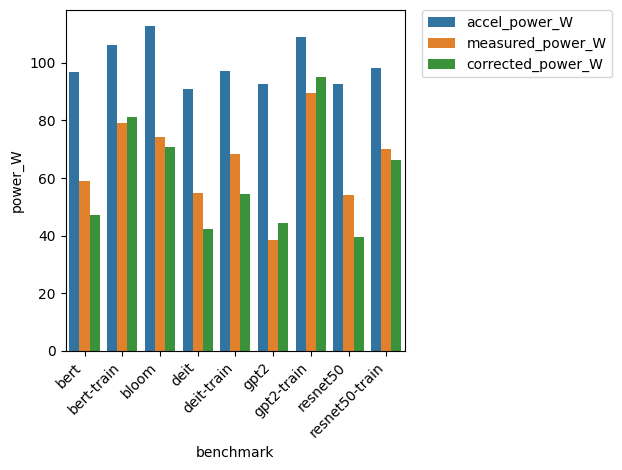

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    correct_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .unpivot(index="benchmark", value_name="power_W", variable_name="type"),
    x="benchmark", y="power_W", hue="type"
)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) 
plt.tight_layout()
plt.savefig("power.png")

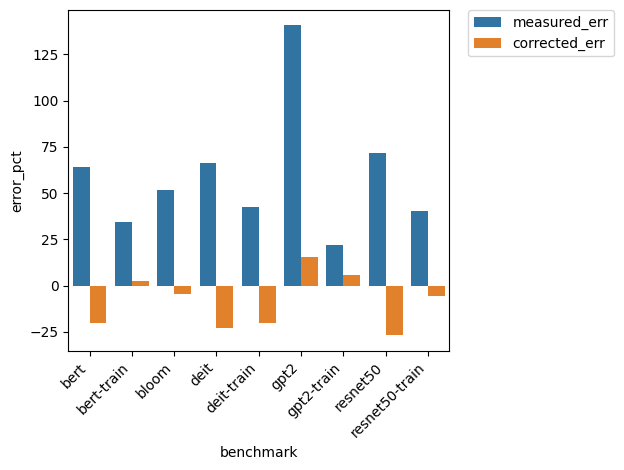

In [95]:
sns.barplot(
    correct_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .select(
        "benchmark",
        measured_err = (pl.col("accel_power_W")/pl.col("measured_power_W") - 1) * 100,
        corrected_err = (pl.col("corrected_power_W")/pl.col("measured_power_W") - 1) * 100,
    )
    .unpivot(index="benchmark", value_name="error_pct", variable_name="type"),
    x="benchmark", y="error_pct", hue="type"
)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) 
plt.tight_layout()
plt.savefig("error.png")

In [26]:
FREQ_MHZ = 1132 

final_df = (
    comp_df.join(idle_df, on="benchmark", how="inner")
    .with_columns([
        # Time (us) = Cycles / (Cycles/us)
        (pl.col("cycles") / FREQ_MHZ).alias("active_time_us"),
    ])
    .with_columns([
        # Energy (uJ) = Power (W) * Time (us)
        # (Watts * Microseconds = Microjoules)
        (pl.col("accel_power_W") * pl.col("active_time_us")).alias("active_energy_uJ")
    ])
    
    .select([
        pl.col("benchmark"),
        pl.col("measure_power_W"),
        pl.col("accel_power_W").alias("old_active_power_W"),
        
        # Corrected Power = (Active Energy + Idle Energy) / (Active Time + Idle Time)
        (
            (pl.col("active_energy_uJ") + pl.col("idle_energy_uJ")) / 
            (pl.col("active_time_us") + pl.col("idle_time_us"))
        ).alias("corrected_power_W")
    ])
)

final_df

benchmark,measure_power_W,old_active_power_W,corrected_power_W
str,f64,f64,f64
"""deit-train""",68.242799,97.265104,33.839222
"""gpt2""",38.570944,92.793675,32.922201
"""resnet50-train""",70.123221,98.370075,34.295256
"""gpt2-train""",89.669436,109.122387,37.838501
"""resnet50""",54.032302,92.827203,33.087296
"""bert""",59.135332,96.99283,32.828422
"""deit""",54.731851,91.044472,33.609477
"""bloom""",74.344924,112.715731,33.370091
"""bert-train""",79.030911,106.186118,36.254898
